Lese JSON-Datei ein...
12923 Straßen werden visualisiert.


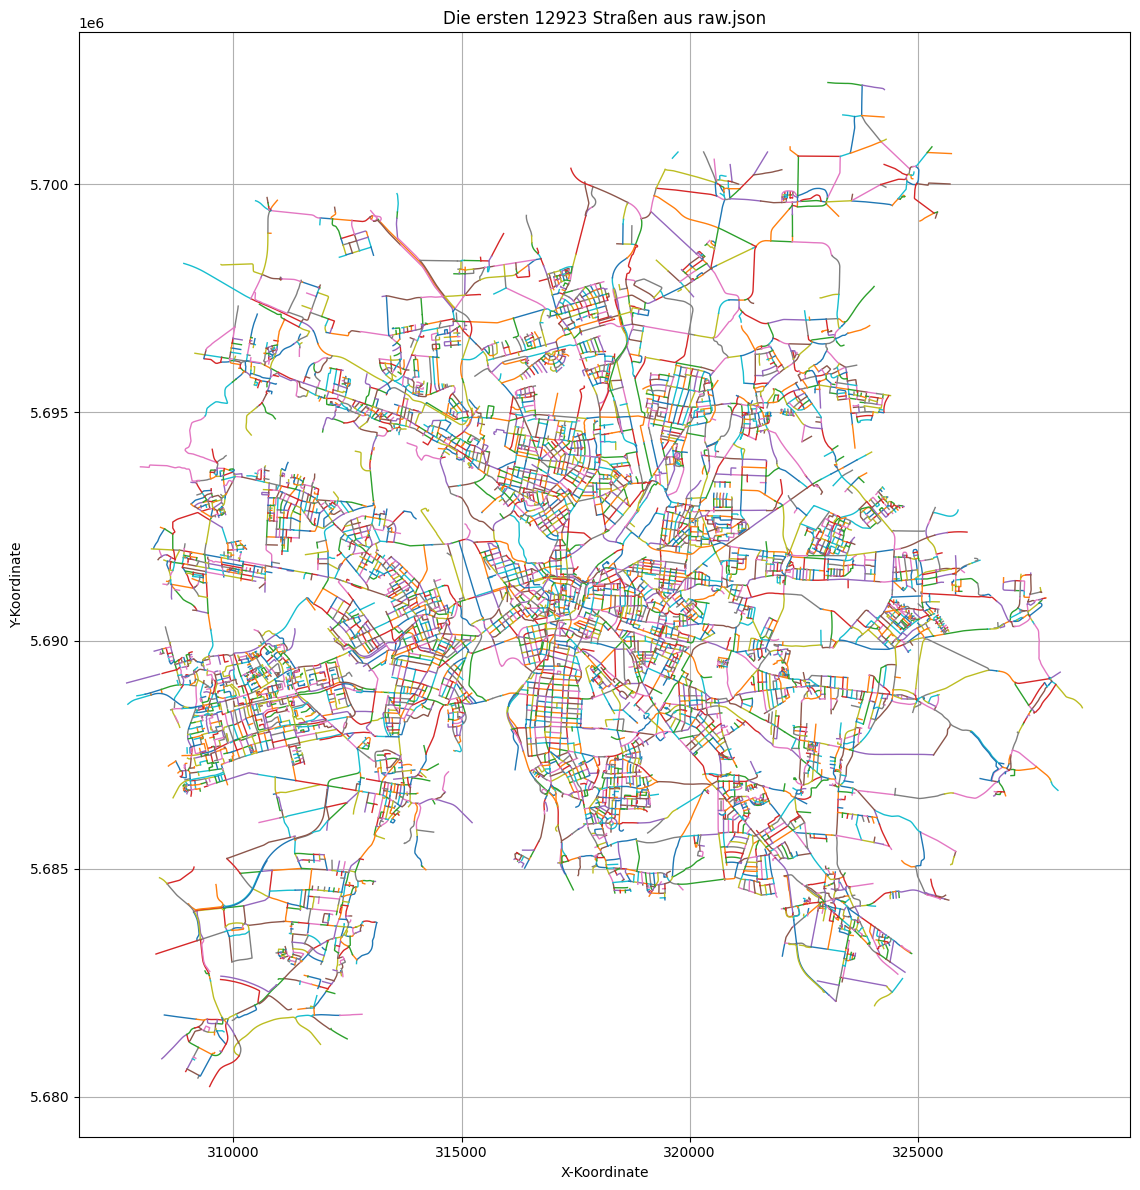

In [ ]:
import json
import matplotlib.pyplot as plt

DATEIPFAD = r"P:\pcloud\Projekte_pcloud\isochrone_map\raw.json"

ANZAHL_STRASSEN = 1000000

# Optional: Straßennamen anzeigen
STRAßENNAMEN_ANZEIGEN = True

print("Lese JSON-Datei ein...")

with open(DATEIPFAD, "r", encoding="utf-8") as datei:
    daten = json.load(datei)

# Alle Features aus der GeoJSON-Datei
features = daten["features"]

# Nur die ersten 100 Straßen
features = features[:ANZAHL_STRASSEN]

print(f"{len(features)} Straßen werden visualisiert.")

fig, ax = plt.subplots(figsize=(12, 12))

for feature in features:

    geometry = feature.get("geometry", {})
    properties = feature.get("properties", {})

    geometry_type = geometry.get("type")
    coordinates = geometry.get("coordinates", [])

    # Straßenname
    strassenname = properties.get("str", "Unbekannte Straße")

    # --------------------------------------------------
    # MultiLineString verarbeiten
    # --------------------------------------------------

    if geometry_type == "MultiLineString":
        for line in coordinates:

            # X- und Y-Koordinaten trennen
            x_werte = [punkt[0] for punkt in line]
            y_werte = [punkt[1] for punkt in line]

            # Linie zeichnen
            ax.plot(x_werte,y_werte,linewidth=1)



# --------------------------------------------------
# Darstellung konfigurieren
# --------------------------------------------------

ax.set_title(f"Die ersten {len(features)} Straßen aus raw.json")

ax.set_xlabel("X-Koordinate")
ax.set_ylabel("Y-Koordinate")

ax.set_aspect("equal")

# Raster optional
ax.grid(True)

plt.tight_layout()
plt.show()

Lade Datei:
P:\pcloud\Projekte_pcloud\isochrone_map\raw.json
Datei erfolgreich geladen.
Lade Datei:
P:\pcloud\Projekte_pcloud\isochrone_map\verkehrsraumeinschraenkungen.json
Datei erfolgreich geladen.
Anzahl Straßen-Segmente: 12923
Anzahl Verkehrseinschränkungen: 1470

Anzahl gezeichneter Einschränkungen: 901

Zeichne Straßen...


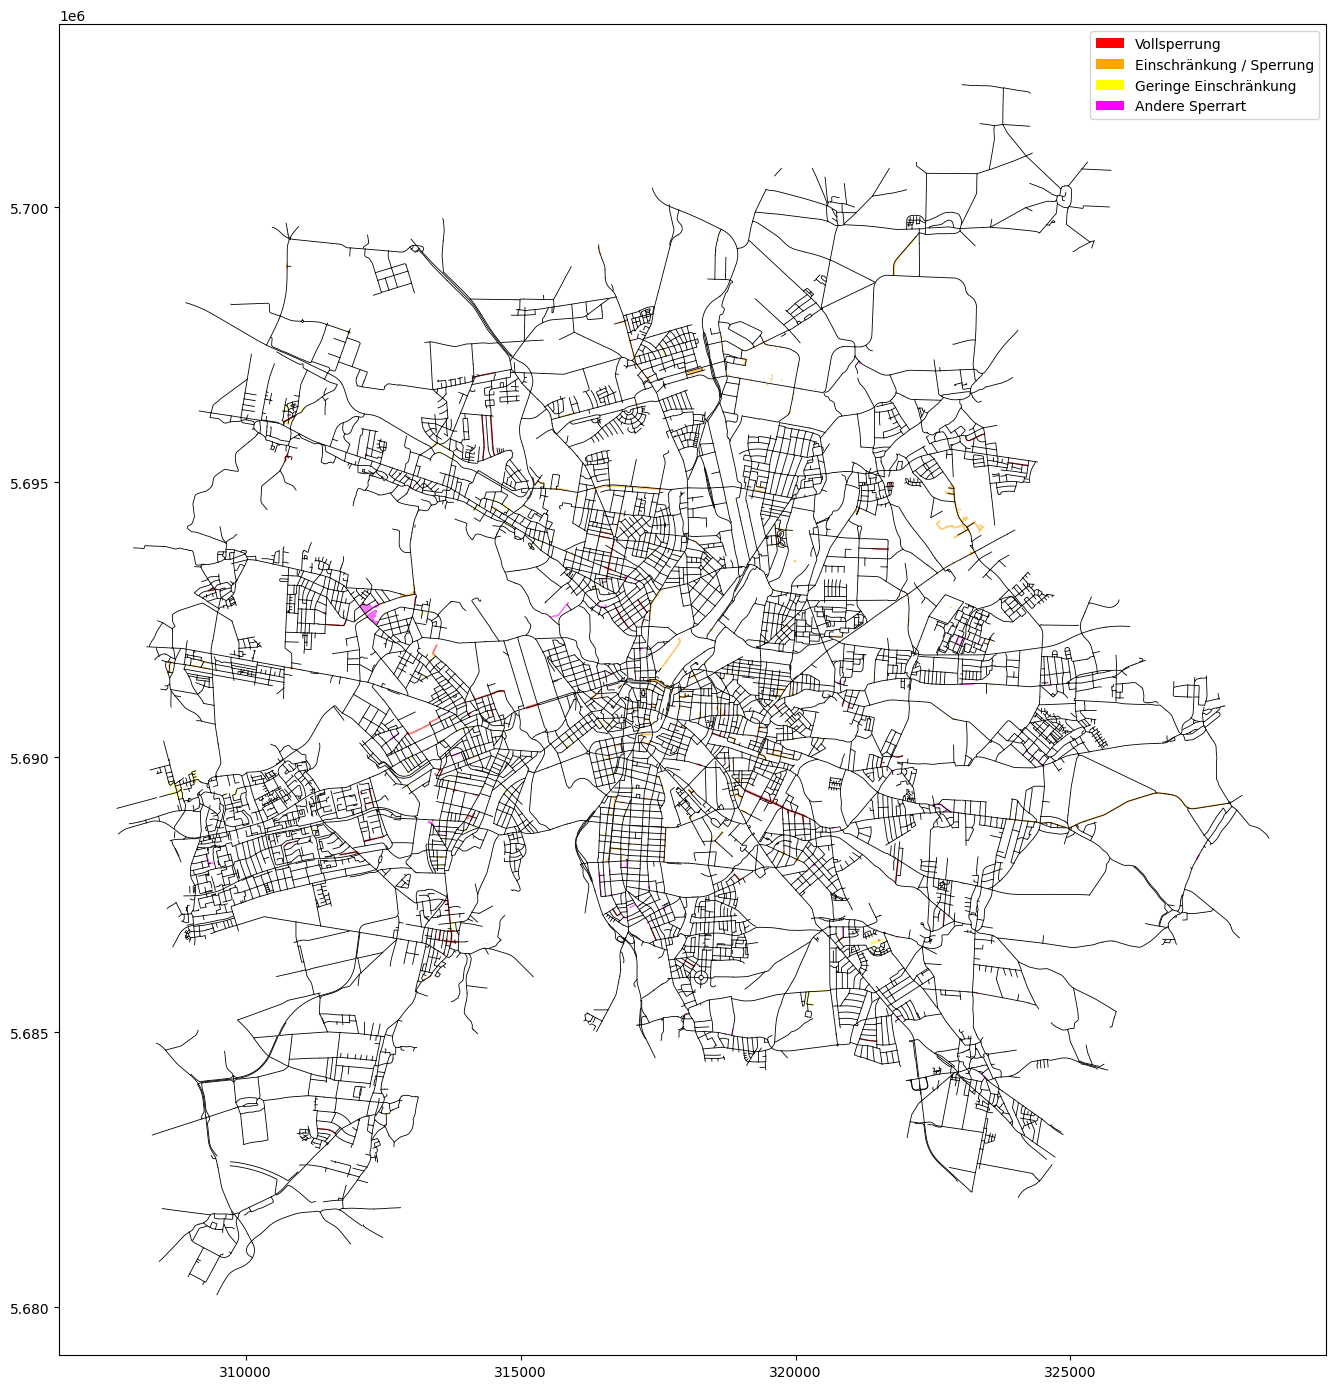

In [ ]:
import json
from pathlib import Path
from datetime import datetime, date

import matplotlib.pyplot as plt
from matplotlib.patches import Patch

ORDNER = Path(r"P:\pcloud\Projekte_pcloud\isochrone_map")

DATEI_STRASSEN = ORDNER / "raw.json"
DATEI_EINSCHRAENKUNGEN = ORDNER / "verkehrsraumeinschraenkungen.json"

NUR_AKTUELLE_EINSCHRAENKUNGEN = True
STRASSEN_LINIENBREITE = 0.6
EINSCHRAENKUNGS_LINIENBREITE = 0.9

def json_laden(dateipfad):
    print(f"Lade Datei:")
    print(dateipfad)

    with open(dateipfad, "r", encoding="utf-8") as datei:
        daten = json.load(datei)

    print(f"Datei erfolgreich geladen.")
    return daten

def datum_lesen(datumswert):
    if not datumswert:
        return None

    try:
        return datetime.strptime(datumswert,"%Y-%m-%d").date()

    except ValueError:
        return None

def einschraenkung_aktuell(properties, aktuelles_datum):
    beginn = datum_lesen(properties.get("beginn"))

    ende = datum_lesen(properties.get("ende"))

    if beginn is not None and beginn > aktuelles_datum:
        return False

    if ende is not None and ende < aktuelles_datum:
        return False

    return True

def farbe_fuer_sperrart(sperrart):
    if sperrart is None:
        return "orange"

    sperrart_klein = sperrart.lower()

    if "vollsperr" in sperrart_klein:
        return "red"

    if "geringe" in sperrart_klein:
        return "yellow"

    if "halb" in sperrart_klein:
        return "orange"

    return "magenta"


strassen_daten = json_laden(DATEI_STRASSEN)
einschraenkungs_daten = json_laden(DATEI_EINSCHRAENKUNGEN)
strassen_features = strassen_daten.get("features",[])
einschraenkungs_features = einschraenkungs_daten.get("features",[])

print(f"Anzahl Straßen-Segmente: {len(strassen_features)}")
print(f"Anzahl Verkehrseinschränkungen: {len(einschraenkungs_features)}")

alle_sperrarten = set()

for feature in einschraenkungs_features:
    properties = feature.get("properties",{})

    sperrart = properties.get("sperrart")

    if sperrart is None:
        alle_sperrarten.add("Keine Angabe")
    else:
        alle_sperrarten.add(sperrart)
 

heute = date.today()

if NUR_AKTUELLE_EINSCHRAENKUNGEN:
    aktive_einschraenkungen = []
    for feature in einschraenkungs_features:
        properties = feature.get("properties",{})

        if einschraenkung_aktuell(properties,heute):
            aktive_einschraenkungen.append(feature)
else:
    aktive_einschraenkungen = (einschraenkungs_features)

print()
print( f"Anzahl gezeichneter Einschränkungen: {len(aktive_einschraenkungen)}")

fig, ax = plt.subplots(figsize=(14, 14))

print()
print("Zeichne Straßen...")

for index, feature in enumerate(strassen_features):
    geometry = feature.get("geometry",{})
    properties = feature.get("properties",{})
    geometry_type = geometry.get("type")
    coordinates = geometry.get("coordinates",[])
    strassenname = properties.get("str","")

    if geometry_type == "MultiLineString":
        for line in coordinates:
            if len(line) < 2:
                continue

            x_werte = [punkt[0] for punkt in line]
            y_werte = [punkt[1] for punkt in line]

            ax.plot(x_werte,y_werte,linewidth=STRASSEN_LINIENBREITE,color="black")

for index, feature in enumerate(aktive_einschraenkungen):
    geometry = feature.get("geometry",{})
    properties = feature.get("properties",{})
    geometry_type = geometry.get("type")
    coordinates = geometry.get("coordinates",[])
    sperrart = properties.get("sperrart")
    adresse = properties.get("adresse","")
    farbe = farbe_fuer_sperrart(sperrart)

    if geometry_type == "MultiPolygon":
        for polygon in coordinates:
            for ring in polygon:
                if len(ring) < 3:
                    continue

                x_werte = [punkt[0]for punkt in ring]
                y_werte = [punkt[1]for punkt in ring]

                # Fläche zeichnen
                ax.fill(x_werte,y_werte,color=farbe,alpha=0.5,linewidth=EINSCHRAENKUNGS_LINIENBREITE)

ax.set_aspect("equal")

legende_elemente = [
    Patch(facecolor="red",label="Vollsperrung"),
    Patch(facecolor="orange",label="Einschränkung / Sperrung"),
    Patch(facecolor="yellow",label="Geringe Einschränkung"),
    Patch(facecolor="magenta",label="Andere Sperrart")
]

ax.legend(handles=legende_elemente,loc="upper right")
plt.tight_layout()
plt.show
                                                                                                                                                                                                                                                                        